## Assignment 10
#### 10. Assignment on Regression technique.

Download temperature data from the link below.
https://www.kaggle.com/venky73/temperaturesof-india?select=temperatures.csv

This data consists of temperatures of INDIA averaging the temperatures of all places month wise. Temperatures values are recorded in CELSIUS

* Apply Linear Regression using a suitable library function and predict the Month-wise temperature.

* Assess the performance of regression models using MSE, MAE and R-Square   
metrics

* Visualize a simple regression model.


#### By **Anushka Salvi, Roll No. 51, SEDA Division, PRN - 1252090036**

1. Import required libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

2. Load the dataset

In [ ]:
df = pd.read_csv("temperatures.csv")
df

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC
0,1901,22.40,24.14,29.07,31.91,33.41,33.18,31.21,30.39,30.47,29.97,27.31,24.49,28.96,23.27,31.46,31.27,27.25
1,1902,24.93,26.58,29.77,31.78,33.73,32.91,30.92,30.73,29.80,29.12,26.31,24.04,29.22,25.75,31.76,31.09,26.49
2,1903,23.44,25.03,27.83,31.39,32.91,33.00,31.34,29.98,29.85,29.04,26.08,23.65,28.47,24.24,30.71,30.92,26.26
3,1904,22.50,24.73,28.21,32.02,32.64,32.07,30.36,30.09,30.04,29.20,26.36,23.63,28.49,23.62,30.95,30.66,26.40
4,1905,22.00,22.83,26.68,30.01,33.32,33.25,31.44,30.68,30.12,30.67,27.52,23.82,28.30,22.25,30.00,31.33,26.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,2013,24.56,26.59,30.62,32.66,34.46,32.44,31.07,30.76,31.04,30.27,27.83,25.37,29.81,25.58,32.58,31.33,27.83
113,2014,23.83,25.97,28.95,32.74,33.77,34.15,31.85,31.32,30.68,30.29,28.05,25.08,29.72,24.90,31.82,32.00,27.81
114,2015,24.58,26.89,29.07,31.87,34.09,32.48,31.88,31.52,31.55,31.04,28.10,25.67,29.90,25.74,31.68,31.87,28.27
115,2016,26.94,29.72,32.62,35.38,35.72,34.03,31.64,31.79,31.66,31.98,30.11,28.01,31.63,28.33,34.57,32.28,30.03


3. Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   YEAR     117 non-null    int64  
 1   JAN      117 non-null    float64
 2   FEB      117 non-null    float64
 3   MAR      117 non-null    float64
 4   APR      117 non-null    float64
 5   MAY      117 non-null    float64
 6   JUN      117 non-null    float64
 7   JUL      117 non-null    float64
 8   AUG      117 non-null    float64
 9   SEP      117 non-null    float64
 10  OCT      117 non-null    float64
 11  NOV      117 non-null    float64
 12  DEC      117 non-null    float64
 13  ANNUAL   117 non-null    float64
 14  JAN-FEB  117 non-null    float64
 15  MAR-MAY  117 non-null    float64
 16  JUN-SEP  117 non-null    float64
 17  OCT-DEC  117 non-null    float64
dtypes: float64(17), int64(1)
memory usage: 16.6 KB


In [ ]:
df.describe()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC
count,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000
mean,1959.000000,23.687436,25.597863,29.085983,31.975812,33.565299,32.774274,31.035897,30.507692,30.486752,29.766581,27.285470,24.608291,29.181368,24.629573,31.517607,31.198205,27.208120
std,33.919021,0.834588,1.150757,1.068451,0.889478,0.724905,0.633132,0.468818,0.476312,0.544295,0.705492,0.714518,0.782644,0.555555,0.911239,0.740585,0.420508,0.672003
min,1901.000000,22.000000,22.830000,26.680000,30.010000,31.930000,31.100000,29.760000,29.310000,29.070000,27.900000,25.700000,23.020000,28.110000,22.250000,29.920000,30.240000,25.740000
25%,1930.000000,23.100000,24.780000,28.370000,31.460000,33.110000,32.340000,30.740000,30.180000,30.120000,29.380000,26.790000,24.040000,28.760000,24.110000,31.040000,30.920000,26.700000
50%,1959.000000,23.680000,25.480000,29.040000,31.950000,33.510000,32.730000,31.000000,30.540000,30.520000,29.780000,27.300000,24.660000,29.090000,24.530000,31.470000,31.190000,27.210000
75%,1988.000000,24.180000,26.310000,29.610000,32.420000,34.030000,33.180000,31.330000,30.760000,30.810000,30.170000,27.720000,25.110000,29.470000,25.150000,31.890000,31.400000,27.610000
max,2017.000000,26.940000,29.720000,32.620000,35.380000,35.840000,34.480000,32.760000,31.840000,32.220000,32.290000,30.110000,28.010000,31.630000,28.330000,34.570000,32.410000,30.030000


In [ ]:
df.shape

(117, 18)

4. Implement Data Preprocessing (No cleaning required as data is already clean)

5. Converting wide format to long format

In [ ]:
df1 = df.melt(
    id_vars=['YEAR'],
    value_vars=['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC'],
    var_name='Month',
    value_name='Temperature'
)

df1

,YEAR,Month,Temperature
0,1901,JAN,22.40
1,1902,JAN,24.93
2,1903,JAN,23.44
3,1904,JAN,22.50
4,1905,JAN,22.00
...,...,...,...
1399,2013,DEC,25.37
1400,2014,DEC,25.08
1401,2015,DEC,25.67
1402,2016,DEC,28.01


6. Converting months to numeric values

In [ ]:
df1['Month'] = pd.to_datetime(df1['Month'], format='%b').dt.month
df1

,YEAR,Month,Temperature
0,1901,1,22.40
1,1902,1,24.93
2,1903,1,23.44
3,1904,1,22.50
4,1905,1,22.00
...,...,...,...
1399,2013,12,25.37
1400,2014,12,25.08
1401,2015,12,25.67
1402,2016,12,28.01


7. Define the features

In [ ]:
X = df1[['Month']]
y = df1['Temperature']

8. Data validation using train test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

9. Apply Linear Regression Model

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Prediction = ", y_pred)

Prediction =  [29.283892   29.08214986 29.12249829 29.12249829 29.24354357 29.00145301
 29.283892   28.92075615 28.92075615 29.16284672 29.00145301 29.12249829
 28.92075615 29.16284672 29.08214986 29.08214986 29.20319514 28.92075615
 29.04180143 29.36458885 29.08214986 29.283892   29.283892   29.20319514
 29.12249829 29.16284672 29.08214986 28.92075615 28.96110458 29.24354357
 29.24354357 28.92075615 28.92075615 29.283892   28.92075615 29.24354357
 29.283892   29.08214986 29.04180143 29.20319514 29.12249829 28.96110458
 29.32424042 28.96110458 29.16284672 29.32424042 29.04180143 29.16284672
 29.00145301 29.00145301 29.12249829 29.24354357 29.12249829 28.96110458
 29.283892   29.04180143 28.92075615 29.24354357 29.00145301 29.283892
 29.04180143 29.04180143 29.283892   29.00145301 29.04180143 29.24354357
 29.24354357 29.12249829 28.92075615 28.96110458 29.24354357 28.96110458
 29.283892   28.96110458 29.08214986 29.00145301 29.12249829 29.12249829
 29.24354357 29.04180143 28.92075615 29

10. Evaluation metrics

In [ ]:
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score: ", r2_score(y_test, y_pred))
print("Root Mean Squared Error", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Mean Absolute Error", mean_absolute_error(y_test, y_pred))

Mean Squared Error: 9.999806682283973
R2 Score:  -0.005573628993982727
Root Mean Squared Error 3.162247093805918
Mean Absolute Error 2.705271869781447


11. Visualization

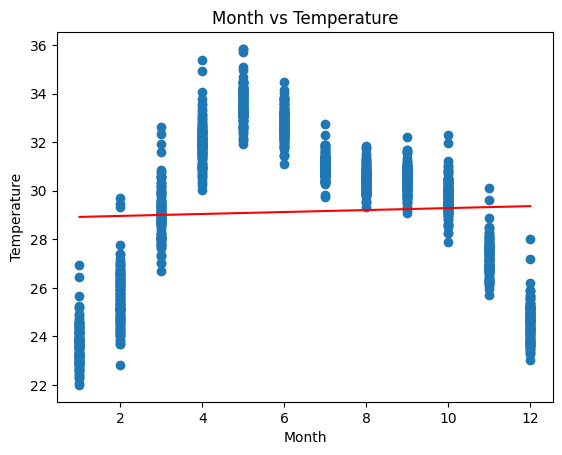

In [ ]:
plt.scatter(X, y)
plt.plot(X, model.predict(X), color="red")

plt.xlabel("Month")
plt.ylabel("Temperature")
plt.title("Month vs Temperature")

plt.show()